In [24]:
import sys
import os
import numpy as np
from sklearn.model_selection import train_test_split
sys.path.append(os.path.abspath('../src'))

from models.cnn_model import *
from utils.visualization import *
import jax
jax.config.update('jax_platform_name', 'cpu')

In [25]:
# Path where the .npy files were saved
input_path = "../data/depths/NPY_SPLITS"

# List and sort the files by name
x_files = sorted([f for f in os.listdir(input_path) if f.startswith("X_part") and f.endswith(".npy")])
y_files = sorted([f for f in os.listdir(input_path) if f.startswith("y_part") and f.endswith(".npy")])

# Load and concatenate the parts
X_data = np.concatenate([np.load(os.path.join(input_path, f)) for f in x_files], axis=0)
y_data = np.concatenate([np.load(os.path.join(input_path, f)) for f in y_files], axis=0)

# Print the shape of the loaded arrays
print(f"X_data shape: {X_data.shape}")
print(f"y_data shape: {y_data.shape}")

X_data shape: (430, 387, 450, 3)
y_data shape: (430, 387, 450, 1)


In [26]:
# Split data into training and testing sets
X_train, X_val, y_train, y_val = train_test_split(X_data, y_data, test_size=0.2, random_state=42)

In [27]:
correlation_map_train = correlation_weigths(X_train, y_train)
correlation_map_val = correlation_weigths(X_val, y_val)
correlation_map_train = jnp.nan_to_num(correlation_map_train, nan=0.0)
correlation_map_val = jnp.nan_to_num(correlation_map_val, nan=0.0)

In [28]:
from flax.training import checkpoints
import os

# =======================
# Initialize base model
# =======================
rng = jax.random.PRNGKey(0)
learning_rate = 1e-3
optimizer = optax.adam(learning_rate)

model = CNNModel(use_correlation=False)
params = model.init(rng, X_train[:1], get_correlation_map_batch(correlation_map_train, 1))
state = TrainState.create(apply_fn=model.apply, params=params, tx=optimizer)

# =======================
# Restore from checkpoint
# =======================
ckpt_dir = os.path.abspath("D:/Proyectos_GitHub/BayesHydroCNN/notebooks/checkpoints_nn")
#ckpt_dir = os.path.abspath("D:/Proyectos_GitHub/adao_tests/notebooks/checkpoints_nn")
state = checkpoints.restore_checkpoint(ckpt_dir=ckpt_dir, target=state)

print("✅ State restored from the most recent checkpoint.")


✅ State restored from the most recent checkpoint.


In [29]:
np.random.seed(42)

# Define the subset size (50% of X_train)
subset_size = int(0.5 * X_train.shape[0])

# Select random indices
subset_indices = np.random.choice(X_train.shape[0], subset_size, replace=False)

# Create the X_train subset
X_train_subset = X_train[subset_indices]
y_train_subset = y_train[subset_indices]
correlation_map_train_subset = correlation_map_train[subset_indices]

# Get the batch size and the expected output shape
batch_size = X_train.shape[0]

# Expand and reshape the correlation map for prediction
correlation_map_batch_train = get_correlation_map_batch(correlation_map_train_subset, batch_size)

# Apply the model
y_pred_train_subset = state.apply_fn(state.params, X_train_subset, correlation_map_batch_train)

In [30]:
# Get the batch size and the expected output shape
batch_size = X_val.shape[0]

# Run a forward pass to determine the expected output shape
sample_output = state.apply_fn(state.params, X_val[:1], jnp.zeros((1, 387, 450, 1)))
output_shape = sample_output.shape  # (1, 392, 456, 1) for example

# Expand and reshape the correlation map for prediction
correlation_map_batch_val = get_correlation_map_batch(correlation_map_val, batch_size)

# Apply the model
y_pred_test = state.apply_fn(state.params, X_val, correlation_map_batch_val)

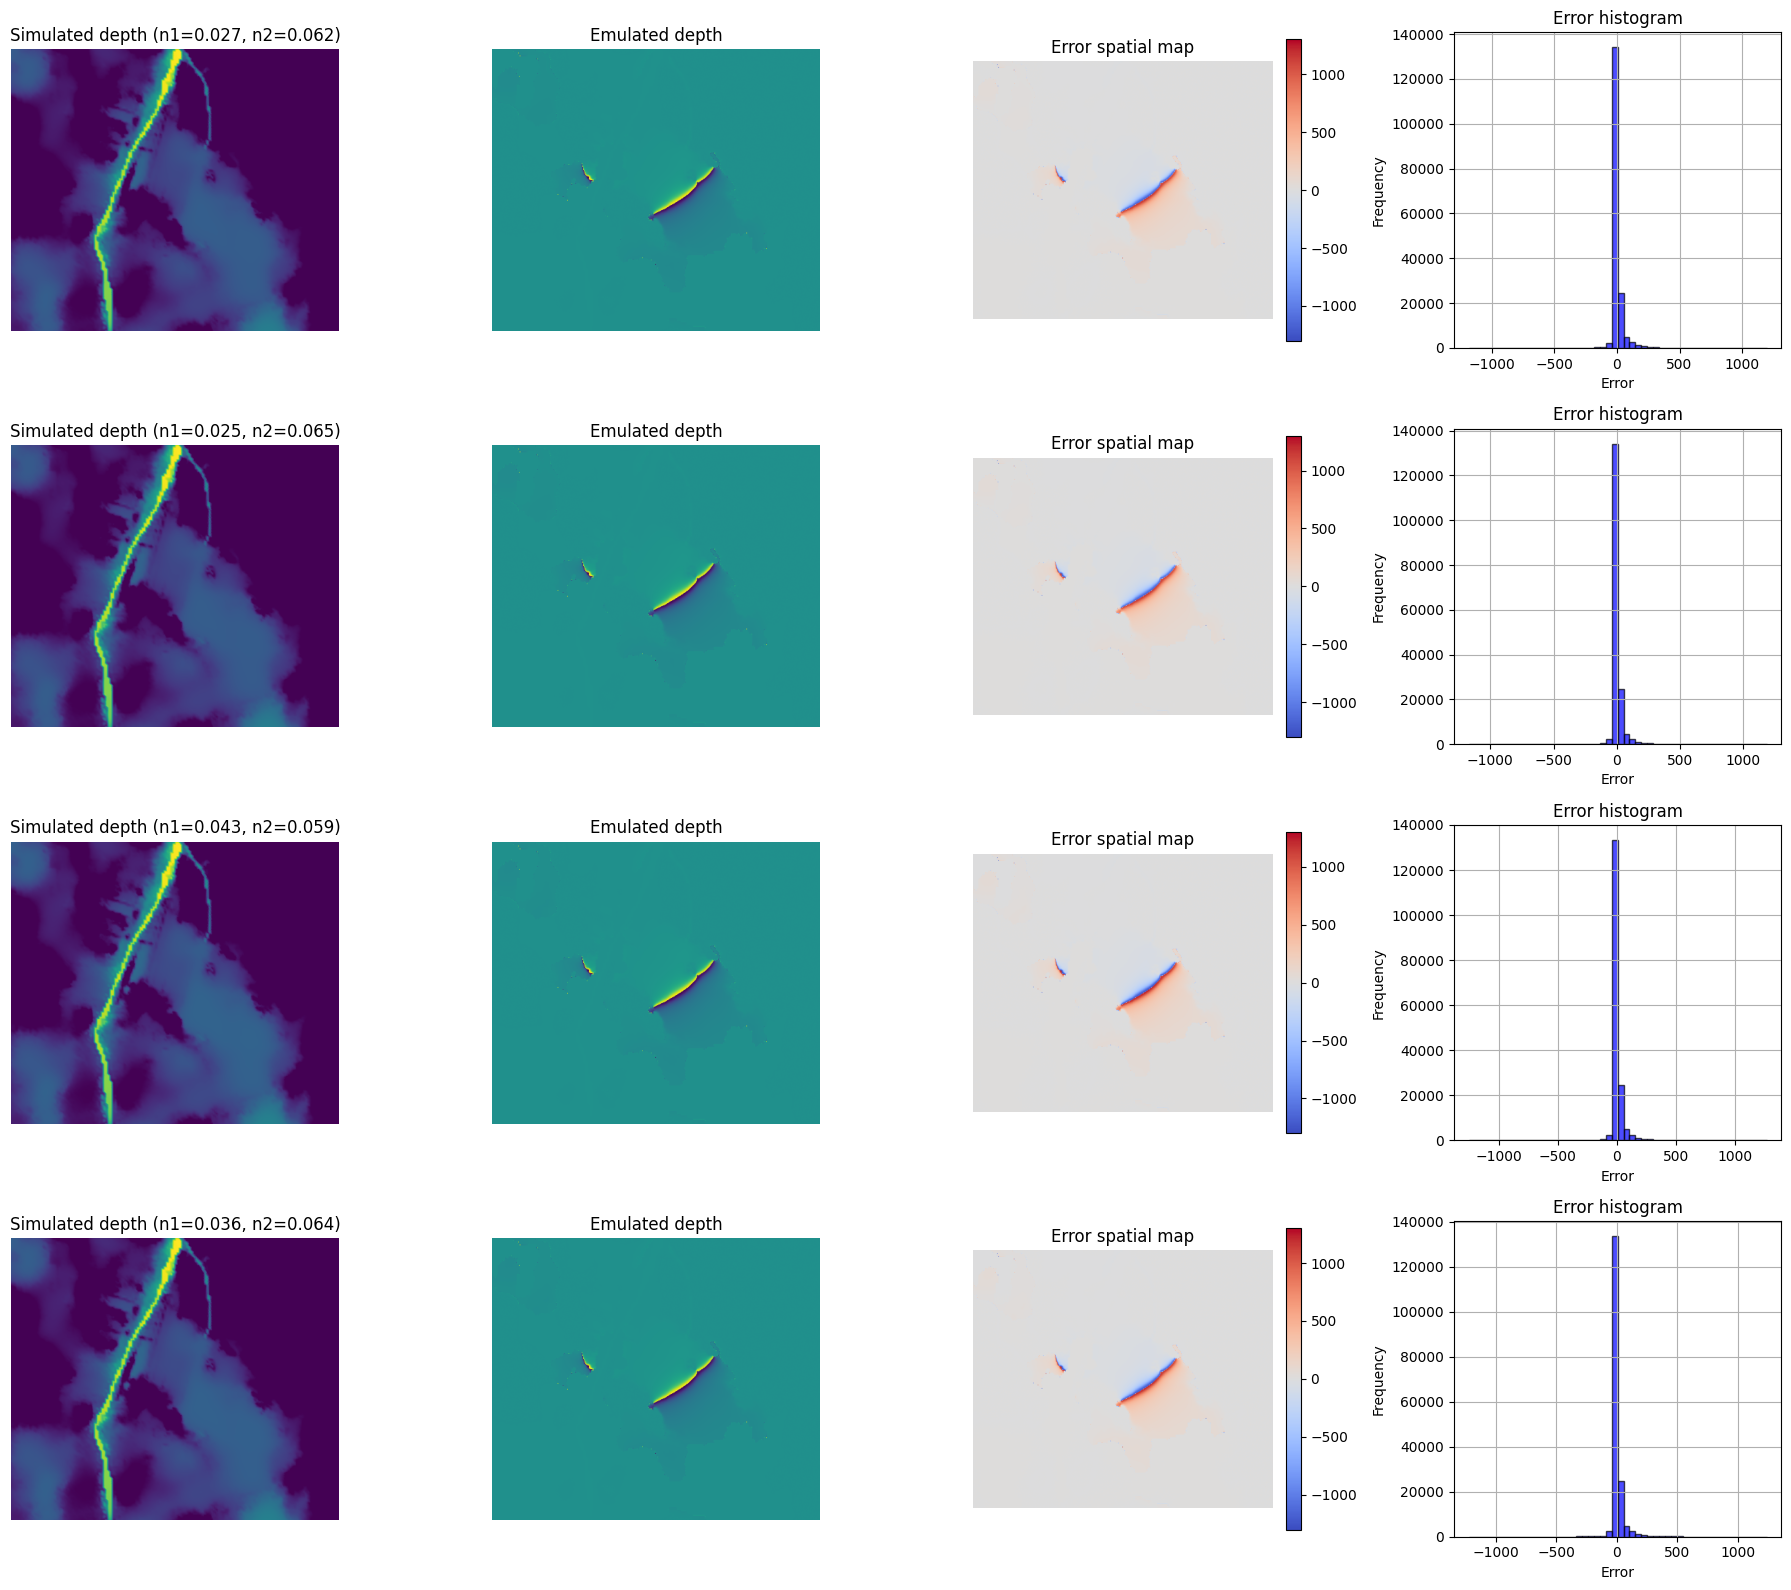

In [31]:
# Select 4 random images from the validation set
num_samples = 4
indices = np.random.choice(X_val.shape[0], num_samples, replace=False)

# Convert from JAX tensor to NumPy for visualization
y_pred_np = np.array(y_pred_test)  # Predictions
y_test_np = np.array(y_val)        # Ground truth

# Compute the difference between the true and predicted images
difference = y_test_np - y_pred_np

# Retrieve roughness values (n1, n2) for each selected image
roughness_values = get_n1_n2(X_val, indices)

# Create a figure with 4 rows and 4 columns (16 subplots total)
fig, axes = plt.subplots(4, 4, figsize=(18, 16))

for i, idx in enumerate(indices):
    # Extract image from the validation set
    sample_image = X_val[idx]  # Expected shape: (height, width, 3)

    # Extract the friction channel
    friction = sample_image[:, :, 0]  # First channel = friction

    # Get roughness values (n1, n2) for this image
    n1, n2 = roughness_values[i]  # ✅ Changed from idx to i

    # Compute the standard deviation of the error
    error_values = difference[idx, :, :, 0].flatten()  # Flatten errors
    std_dev = np.std(error_values)  # Standard deviation

    # Subplot row position
    row = i  # Image row

    # 1️⃣ **Ground Truth Image**
    axes[row, 0].imshow(y_test_np[idx, :, :, 0], cmap="viridis")
    axes[row, 0].set_title(f"Simulated depth (n1={n1:.3f}, n2={n2:.3f})")
    axes[row, 0].axis("off")

    # 2️⃣ **Predicted Image**
    axes[row, 1].imshow(y_pred_np[idx, :, :, 0], cmap="viridis")
    axes[row, 1].set_title("Emulated depth")
    axes[row, 1].axis("off")

    # 3️⃣ **Difference between Ground Truth and Prediction**
    im1 = axes[row, 2].imshow(difference[idx, :, :, 0], cmap="coolwarm", 
                              vmin=-np.max(abs(difference)), vmax=np.max(abs(difference)))
    axes[row, 2].set_title("Error spatial map")
    fig.colorbar(im1, ax=axes[row, 2], fraction=0.046, pad=0.04)
    axes[row, 2].axis("off")

    # 4️⃣ **Error Histogram**
    axes[row, 3].hist(error_values, bins=50, color='blue', edgecolor='black', alpha=0.7)
    axes[row, 3].set_xlabel("Error")
    axes[row, 3].set_ylabel("Frequency")
    axes[row, 3].set_title("Error histogram")
    axes[row, 3].grid(True)

# Adjust layout
plt.tight_layout()

# Save the figure
plt.savefig("subplots_results222.png", dpi=300)

# Display the figure
plt.show()